# 02 — Modelo Preditivo de NPS
**Tech Challenge Fase 1 — NPS Preditivo**

**Pergunta do modelo:** conseguimos **antecipar a insatisfação do cliente a partir de dados operacionais, antes da aplicação da pesquisa de NPS**?

Seguimos o princípio do CRISP-DM *“simples antes de complexo”*: começamos por um baseline interpretável (Regressão Linear / Logística) e comparamos com Random Forest. Reutilizamos `nps/model.py`.

In [1]:
import pandas as pd
from IPython.display import Image, display

from nps import model
from nps.config import PROCESSED_DATA_FILE, FIGURES_DIR, MODELS_DIR

df = pd.read_csv(PROCESSED_DATA_FILE)

## 1. Variável alvo e variáveis de entrada
- **Regressão:** `nps_score` (0–10).
- **Classificação:** `is_detractor` = 1 quando `nps_score < 7` (cliente insatisfeito).
- **Features:** apenas variáveis operacionais disponíveis **antes** da pesquisa.
- **Exclusão por vazamento (leakage):** `repeat_purchase_30d` e `csat_internal_score` — são sinais de satisfação / co-resultados da própria pesquisa e não estariam disponíveis no momento da predição. `customer_region` entra via one-hot encoding.

In [2]:
x, y_reg, y_clf = model.get_features_targets(df)
print('Nº de features:', x.shape[1])
print(list(x.columns))
print('\nBalanceamento do alvo de classificação (is_detractor):')
print(y_clf.value_counts(normalize=True).round(3).to_dict())

Nº de features: 14
['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count', 'customer_region']

Balanceamento do alvo de classificação (is_detractor):
{1: 0.844, 0: 0.156}


## 2. Regressão - estimar a nota de NPS
Divisão treino/teste 80/20 + validação cruzada (5 folds). Métricas: RMSE e MAE (em pontos de NPS) e R².

In [ ]:
reg = model.train_regression(x, y_reg)
print('Melhor modelo (por CV R²):', reg['best_name'])
pd.DataFrame(reg['metrics']).T

Melhor modelo (por CV R²): LinearRegression


,rmse,mae,r2,cv_r2_mean,cv_r2_std
LinearRegression,1.690,1.335,0.548,0.554,0.040
RandomForestRegressor,1.736,1.386,0.523,0.526,0.037


## 3. Classificação — risco de detrator
Divisão estratificada 80/20 + validação cruzada. Métricas: precisão, recall, F1 e AUC.

In [ ]:
clf = model.train_classification(x, y_clf)
print('Melhor modelo (por CV AUC):', clf['best_name'])
pd.DataFrame(clf['metrics']).T

Melhor modelo (por CV AUC): LogisticRegression


,accuracy,precision,recall,f1,roc_auc,cv_auc_mean,cv_auc_std
LogisticRegression,0.858,0.886,0.955,0.919,0.868,0.896,0.011
RandomForestClassifier,0.866,0.877,0.979,0.925,0.867,0.874,0.028


## 4. Quais fatores o modelo usa?
Os **coeficientes padronizados** do modelo linear (impacto por +1 desvio-padrão) confirmam a EDA: atraso, reclamações, tempo de resolução e contatos são os que mais derrubam o NPS. A importância do Random Forest é mostrada **apenas para comparação**, ela infla variáveis de alta cardinalidade e baixo sinal (ex.: `order_value`), por isso lideramos pela leitura linear.

Melhor regressão: LinearRegression | Melhor classificação: LogisticRegression


,coef_padronizado
delivery_delay_days,-1.3597
complaints_count,-0.6766
resolution_time_days,-0.5134
customer_service_contacts,-0.4178
customer_region_Centro-Oeste,-0.1296
freight_value,-0.1051
customer_tenure_months,-0.0564
discount_value,-0.0442
customer_region_Nordeste,-0.0097
customer_region_Sudeste,0.0010


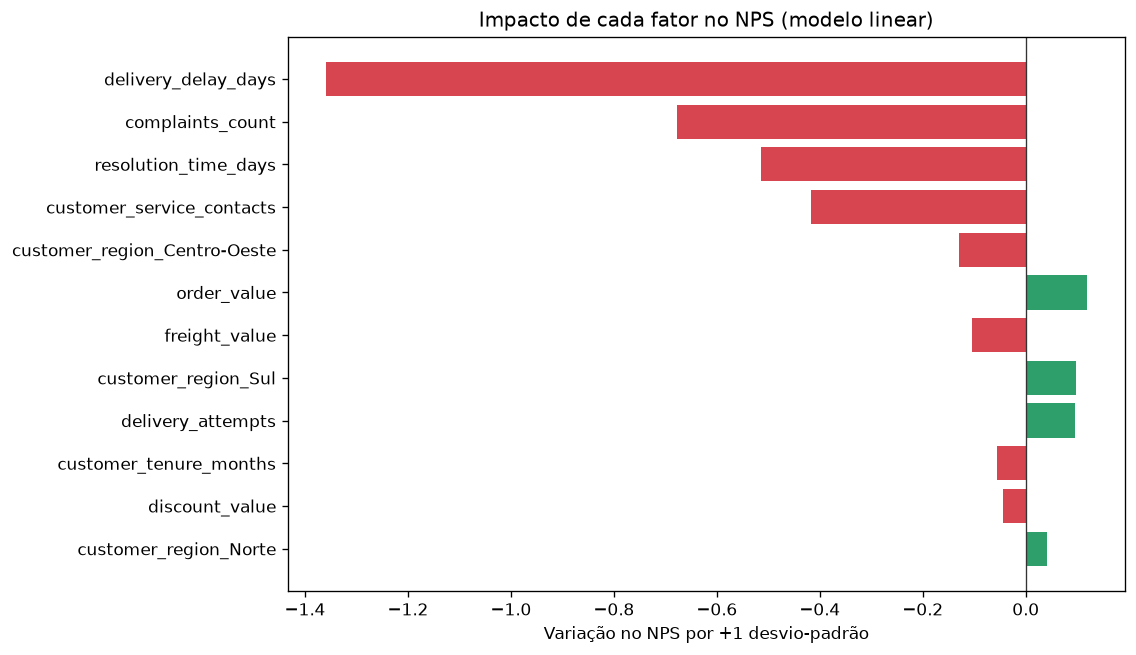

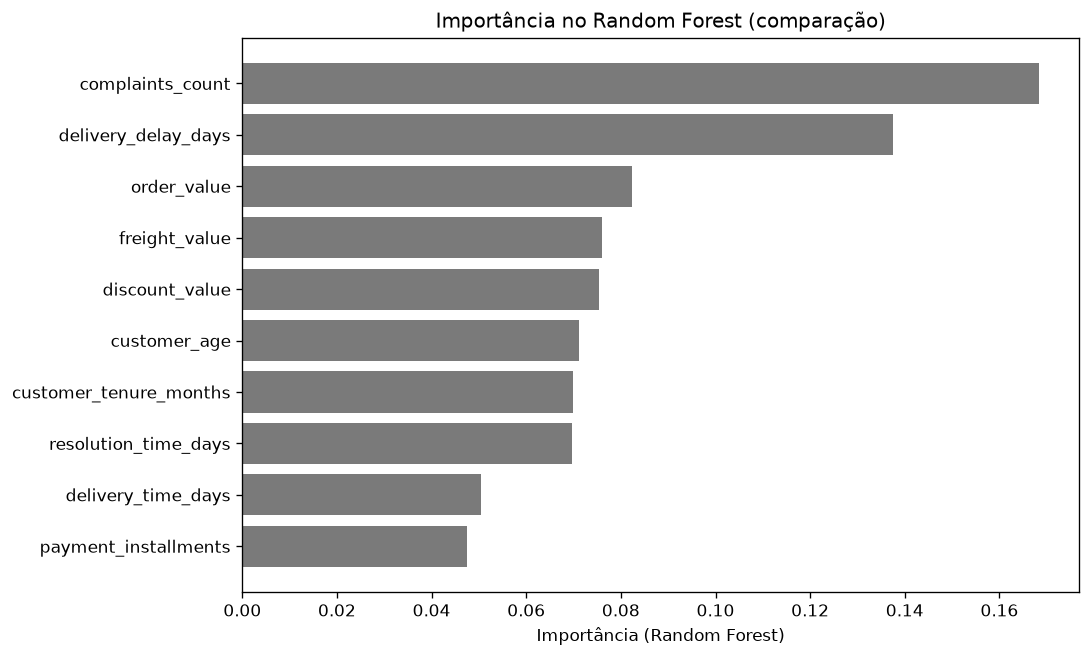

In [ ]:
# Treina ambos os alvos e salva modelos + metrics.json + figuras (usa os caminhos do config)
summary = model.run_pipeline()
print('Melhor regressão:', summary['best_regression'],
      '| Melhor classificação:', summary['best_classification'])
coefs = pd.Series(summary['linear_coefficients']).sort_values()
display(coefs.to_frame('coef_padronizado'))
display(Image(str(FIGURES_DIR / 'model_coefficients.png')))
display(Image(str(FIGURES_DIR / 'feature_importance.png')))

## 5. Avaliação do classificador
AUC ≈ 0,87 indica boa capacidade de **ordenar** clientes por risco. Atenção: como ~84% já são detratores, a acurácia é enganosa (lição do Cap. 3 — metas de negócio × analíticas). O valor prático está no **score de probabilidade** para priorização, não no rótulo cru.

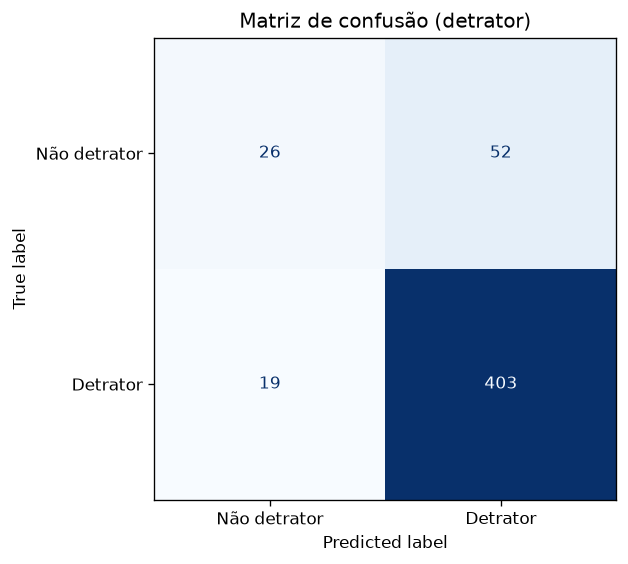

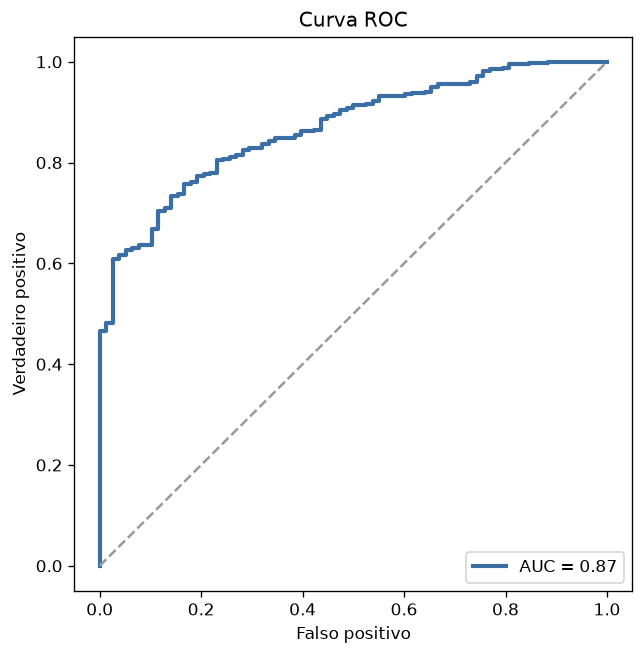

              precision    recall  f1-score   support

Não detrator       0.58      0.33      0.42        78
    Detrator       0.89      0.95      0.92       422

    accuracy                           0.86       500
   macro avg       0.73      0.64      0.67       500
weighted avg       0.84      0.86      0.84       500



In [ ]:
display(Image(str(FIGURES_DIR / 'confusion_matrix.png')))
display(Image(str(FIGURES_DIR / 'roc_curve.png')))
print(summary['classification_report'])

## 6. Como usar na prática - score de risco
O classificador gera, para cada pedido, uma **probabilidade de detrator**. A empresa pode ranquear os pedidos em aberto e disparar ações preventivas (alerta de atraso, contato proativo, compensação) **antes** de o cliente responder à pesquisa.

In [ ]:
import joblib
clf_model = joblib.load(MODELS_DIR / 'detractor_classifier.pkl')
sample = x.head(8).copy()
sample['risco_detrator'] = clf_model.predict_proba(x.head(8))[:, 1].round(3)
cols = ['delivery_delay_days', 'complaints_count', 'customer_service_contacts', 'risco_detrator']
sample[cols].sort_values('risco_detrator', ascending=False)

,delivery_delay_days,complaints_count,customer_service_contacts,risco_detrator
5,5,5,2,0.997
6,3,6,3,0.993
1,4,3,0,0.988
2,1,7,4,0.986
3,2,4,1,0.981
7,5,2,0,0.969
0,2,3,0,0.871
4,1,3,1,0.530


## 7. Conclusões e limitações
- **Conclusão:** dados operacionais explicam ~55% da variância do NPS (R²) e separam detratores com AUC ≈ 0,87 — dá para **antecipar** insatisfação antes da pesquisa.
- **Simples venceu complexo:** o modelo linear/logístico igualou ou superou o Random Forest, então ficamos com o modelo interpretável.
- **Limitações:** (1) base sintética/histórica — validar com dados reais e teste A/B antes de produção; (2) forte desbalanceamento (84% detratores); (3) correlação ≠ causalidade; (4) o modelo aprende padrões operacionais, não causas externas (ex.: clima, transportadora).